🔌 Conectando ao Google Drive...
Mounted at /content/drive
📦 Extraindo dataset do backup (Aguarde)...
✅ Dataset extraído e limpo!

🔄 Carregando imagens para a IA...
Found 25331 files belonging to 8 classes.
Using 20265 files for training.
Found 25331 files belonging to 8 classes.
Using 5066 files for validation.
✅ Classes identificadas (8): ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']

🧠 Construindo o modelo CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,672 (15.22 MB)

 Trainable params: 3,989,672 (15.22 MB)

 Non-trainable params: 0 (0.00 B)


🚀 INICIANDO TREINAMENTO (10 Épocas)...
Epoch 1/10
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 211s 142ms/step - accuracy: 0.5326 - loss: 1.3126 - val_accuracy: 0.5803 - val_loss: 1.1718
Epoch 2/10
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 199s 139ms/step - accuracy: 0.5877 - loss: 1.1482 - val_accuracy: 0.6125 - val_loss: 1.0640
Epoch 3/10
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 194s 135ms/step - accuracy: 0.6250 - loss: 1.0465 - val_accuracy: 0.6330 - val_loss: 1.0175
Epoch 4/10
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 198s 138ms/step - accuracy: 0.6481 - loss: 0.9641 - val_accuracy: 0.6202 - val_loss: 1.0603
Epoch 5/10
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 194s 134ms/step - accuracy: 0.6816 - loss: 0.8675 - val_accuracy: 0.6214 - val_loss: 1.0538
Epoch 6/10
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 203s 135ms/step - accuracy: 0.7270 - loss: 0.7480 - val_accuracy: 0.6459 - val_loss: 1.1050
Epoch 7/10
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 203s 136ms/step - accuracy: 0.7802 - loss: 0.6123 - val_accuracy: 0.6459 - val_loss: 1.2079
Epoch 8/10
1267/1267 ━

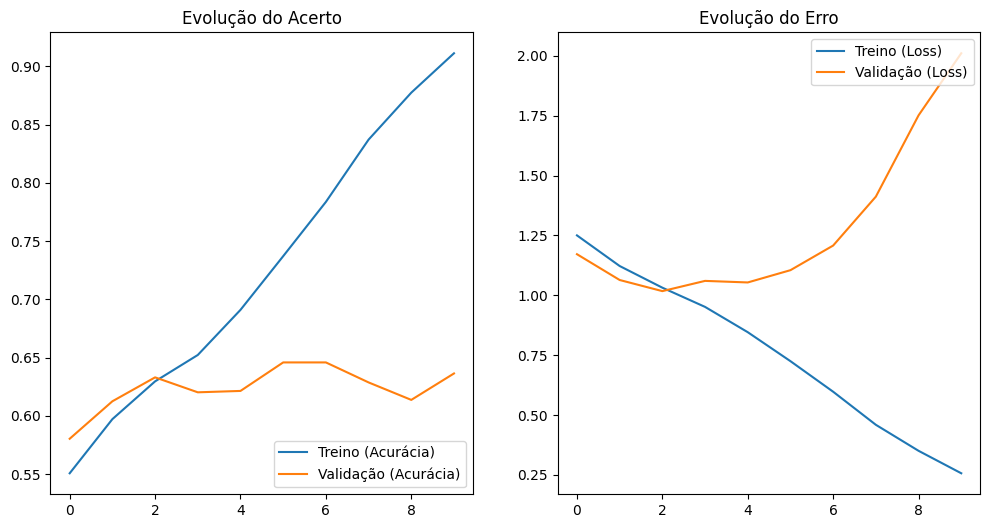

✅ SUCESSO! Modelo salvo em: /content/drive/MyDrive/PIBIC_Melanoma/modelo_treinado_v1.keras


In [ ]:
# -----------------------------------------------------------
# PROJETO: Identificação Automatizada de Lesões de Pele (PIBIC)
# ALUNO: [Davi de Jesus Almeida Nery]
# ETAPA: Desenvolvimento e Treinamento Inicial (CNN)
# -----------------------------------------------------------

import os
import zipfile
import shutil
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from google.colab import drive

# --- 1. CONFIGURAÇÃO E ACESSO AO DRIVE ---
print("🔌 Conectando ao Google Drive...")
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Caminhos dos arquivos
caminho_zip_drive = '/content/drive/MyDrive/PIBIC_Melanoma/dataset_PRONTO.zip'
pasta_dataset = '/content/dataset_final'
local_zip = '/content/dataset_pronto.zip'

# --- 2. CARREGAMENTO DOS DADOS ---
# Verifica se as imagens já estão na máquina do Colab
if not os.path.exists(pasta_dataset):
    print("📦 Extraindo dataset do backup (Aguarde)...")
    shutil.copy(caminho_zip_drive, local_zip)
    with zipfile.ZipFile(local_zip, 'r') as zip_ref:
        zip_ref.extractall(pasta_dataset)

    # Limpeza: Remove pastas que não são doenças (evita erros)
    for intruso in ['ISIC_2019_Training_Input', 'UNK']:
        path = os.path.join(pasta_dataset, intruso)
        if os.path.exists(path): shutil.rmtree(path)
    print("✅ Dataset extraído e limpo!")
else:
    print("⚡ Dataset já está pronto para uso.")

# Configurações para evitar estouro de memória RAM
batch_size = 16       # Lote de 16 imagens por vez
img_height = 180      # Redimensionado para 180px
img_width = 180

print(f"\n🔄 Carregando imagens para a IA...")

# Separação Treino (80%) e Validação (20%)
# O 'seed=123' garante que o teste seja sempre honesto e igual
train_ds = tf.keras.utils.image_dataset_from_directory(
    pasta_dataset,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    pasta_dataset,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"✅ Classes identificadas ({num_classes}): {class_names}")

# Otimização de leitura (Cache/Buffer)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(200).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# --- 3. ARQUITETURA DA REDE NEURAL (CNN) ---
print("\n🧠 Construindo o modelo CNN...")
model = models.Sequential([
    # Normalização: Transforma pixels de 0-255 para 0-1
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    # Camadas de Convolução (Extraem características como bordas e texturas)
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Camadas de Classificação (Tomada de decisão)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax') # 8 Saídas (Probabilidades)
])

# Compilação
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model.summary()

# --- 4. TREINAMENTO ---
print("\n🚀 INICIANDO TREINAMENTO (10 Épocas)...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# --- 5. RESULTADOS E EXPORTAÇÃO ---
print("\n📊 Gerando gráficos de desempenho...")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(10)

plt.figure(figsize=(12, 6))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Treino (Acurácia)')
plt.plot(epochs_range, val_acc, label='Validação (Acurácia)')
plt.legend(loc='lower right')
plt.title('Evolução do Acerto')

# Gráfico de Erro (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Treino (Loss)')
plt.plot(epochs_range, val_loss, label='Validação (Loss)')
plt.legend(loc='upper right')
plt.title('Evolução do Erro')
plt.show()

# Salvar o modelo treinado no Google Drive
caminho_modelo = '/content/drive/MyDrive/PIBIC_Melanoma/modelo_treinado_v1.keras'
model.save(caminho_modelo)
print(f"✅ SUCESSO! Modelo salvo em: {caminho_modelo}")

🔌 Conectando ao Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚡ Dataset já está pronto para uso.

🔄 Carregando imagens para a IA...
Found 25331 files belonging to 10 classes.
Using 17732 files for training.
Found 25331 files belonging to 10 classes.
Using 7599 files for validation.
✅ Classes identificadas (10): ['AK', 'BCC', 'BKL', 'DF', 'ISIC_2019_Training_Input', 'MEL', 'NV', 'SCC', 'UNK', 'VASC']

🧠 Construindo o modelo CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,930 (15.22 MB)

 Trainable params: 3,989,930 (15.22 MB)

 Non-trainable params: 0 (0.00 B)


🚀 INICIANDO TREINAMENTO (10 Épocas)...
Epoch 1/10
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 212s 164ms/step - accuracy: 0.5201 - loss: 1.3410 - val_accuracy: 0.5865 - val_loss: 1.1832
Epoch 2/10
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 244s 156ms/step - accuracy: 0.5878 - loss: 1.1517 - val_accuracy: 0.6232 - val_loss: 1.0755
Epoch 3/10
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 230s 178ms/step - accuracy: 0.6249 - loss: 1.0479 - val_accuracy: 0.6209 - val_loss: 1.0726
Epoch 4/10
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 223s 181ms/step - accuracy: 0.6511 - loss: 0.9706 - val_accuracy: 0.6317 - val_loss: 1.0283
Epoch 5/10
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 200s 159ms/step - accuracy: 0.6753 - loss: 0.8832 - val_accuracy: 0.6415 - val_loss: 1.0503
Epoch 6/10
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 201s 159ms/step - accuracy: 0.7177 - loss: 0.7730 - val_accuracy: 0.6321 - val_loss: 1.0701
Epoch 7/10
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 202s 159ms/step - accuracy: 0.7738 - loss: 0.6325 - val_accuracy: 0.6453 - val_loss: 1.1671
Epoch 8/10
1109/1109 ━

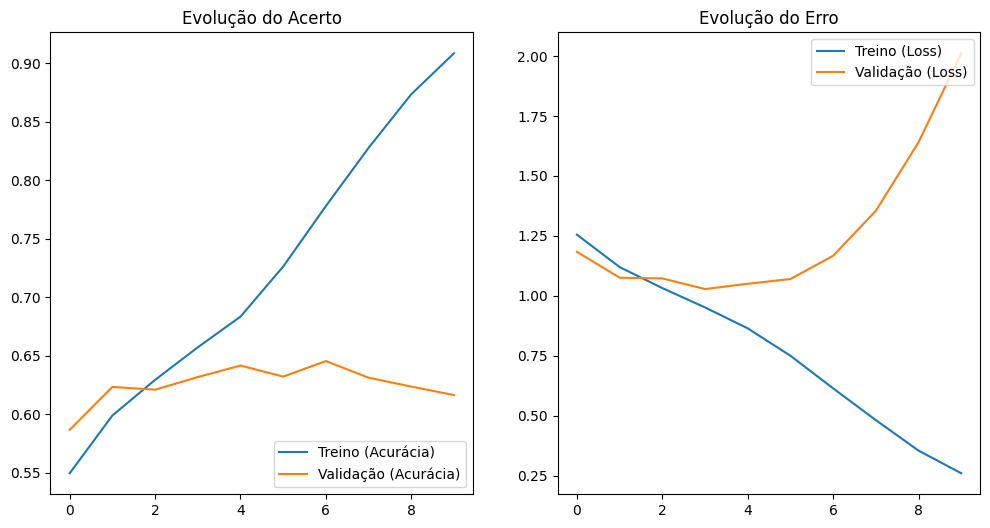

✅ SUCESSO! Modelo salvo em: /content/drive/MyDrive/PIBIC_Melanoma/modelo_treinado_v1.keras


In [ ]:
import os
import zipfile
import shutil
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from google.colab import drive

# --- 1. CONFIGURAÇÃO E ACESSO AO DRIVE ---
print("🔌 Conectando ao Google Drive...")
# montar (tentar montar sempre é seguro no Colab)
drive.mount('/content/drive')

# Caminhos dos arquivos
caminho_zip_drive = '/content/drive/MyDrive/PIBIC_Melanoma/dataset_PRONTO.zip'
pasta_dataset = '/content/dataset_final'
local_zip = '/content/dataset_pronto.zip'

# --- 2. CARREGAMENTO DOS DADOS ---
# Verifica se as imagens já estão na máquina do Colab
if not os.path.exists(pasta_dataset):
    print("📦 Extraindo dataset do backup (Aguarde)...")
    # checagem: existe o zip no Drive?
    if not os.path.exists(caminho_zip_drive):
        raise FileNotFoundError(f"Backup zip não encontrado em: {caminho_zip_drive}. Verifique se o arquivo está no Drive.")
    shutil.copy(caminho_zip_drive, local_zip)
    with zipfile.ZipFile(local_zip, 'r') as zip_ref:
        zip_ref.extractall(pasta_dataset)

    # Limpeza: Remove pastas que não são doenças (evita erros)
    for intruso in ['ISIC_2019_Training_Input', 'UNK']:
        path = os.path.join(pasta_dataset, intruso)
        if os.path.exists(path): shutil.rmtree(path)

    # Ajuste automático: se o zip extraiu um único diretório no topo, use-o
    top_dirs = [d for d in os.listdir(pasta_dataset) if os.path.isdir(os.path.join(pasta_dataset, d))]
    if len(top_dirs) == 1:
        candidate = os.path.join(pasta_dataset, top_dirs[0])
        # se esse candidato tem subpastas (provavelmente são as classes), então apontamos pra ele
        subdirs = [d for d in os.listdir(candidate) if os.path.isdir(os.path.join(candidate, d))]
        if len(subdirs) > 0:
            pasta_dataset = candidate
            print(f"⚙️ Ajustei pasta_dataset para o nível correto: {pasta_dataset}")

    print("✅ Dataset extraído e limpo!")
else:
    print("⚡ Dataset já está pronto para uso.")

# Configurações para evitar estouro de memória RAM
batch_size = 16       # Lote de 16 imagens por vez
img_height = 180      # Redimensionado para 180px
img_width = 180

print(f"\n🔄 Carregando imagens para a IA...")

# Separação Treino (70%) e Validação (30%)
# O 'seed=123' garante que o teste seja sempre honesto e igual
train_ds = tf.keras.utils.image_dataset_from_directory(
    pasta_dataset,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    pasta_dataset,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"✅ Classes identificadas ({num_classes}): {class_names}")

# Otimização de leitura (Cache/Buffer)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(200).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# --- 3. ARQUITETURA DA REDE NEURAL (CNN) ---
print("\n🧠 Construindo o modelo CNN...")
model = models.Sequential([
    # Normalização: Transforma pixels de 0-255 para 0-1
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    # Camadas de Convolução (Extraem características como bordas e texturas)
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Camadas de Classificação (Tomada de decisão)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax') # 8 Saídas (Probabilidades)
])

# Compilação
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model.summary()

# --- 4. TREINAMENTO ---
print("\n🚀 INICIANDO TREINAMENTO (10 Épocas)...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# --- 5. RESULTADOS E EXPORTAÇÃO ---
print("\n📊 Gerando gráficos de desempenho...")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(10)

plt.figure(figsize=(12, 6))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Treino (Acurácia)')
plt.plot(epochs_range, val_acc, label='Validação (Acurácia)')
plt.legend(loc='lower right')
plt.title('Evolução do Acerto')

# Gráfico de Erro (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Treino (Loss)')
plt.plot(epochs_range, val_loss, label='Validação (Loss)')
plt.legend(loc='upper right')
plt.title('Evolução do Erro')
plt.show()

# Salvar o modelo treinado no Google Drive
caminho_modelo = '/content/drive/MyDrive/PIBIC_Melanoma/modelo_treinado_v1.keras'
model.save(caminho_modelo)
print(f"✅ SUCESSO! Modelo salvo em: {caminho_modelo}")


🔌 Conectando ao Google Drive...
Mounted at /content/drive
📦 Extraindo dataset do backup (Aguarde)...
✅ Dataset extraído e limpo!

🔄 Carregando imagens (Divisão 70/30)...
Found 25331 files belonging to 8 classes.
Using 17732 files for training.
Found 25331 files belonging to 8 classes.
Using 7599 files for validation.
✅ Classes identificadas (8): ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']

🧠 Construindo o modelo CNN com Regularização...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,024,264 (30.61 MB)

 Trainable params: 8,024,264 (30.61 MB)

 Non-trainable params: 0 (0.00 B)


🚀 INICIANDO TREINAMENTO (V2)...
Epoch 1/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 218s 291ms/step - accuracy: 0.4795 - loss: 1.6154 - val_accuracy: 0.5161 - val_loss: 1.3133
Epoch 2/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 217s 306ms/step - accuracy: 0.5220 - loss: 1.3116 - val_accuracy: 0.5344 - val_loss: 1.2660
Epoch 3/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 218s 302ms/step - accuracy: 0.5454 - loss: 1.2501 - val_accuracy: 0.5615 - val_loss: 1.2351
Epoch 4/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 218s 304ms/step - accuracy: 0.5493 - loss: 1.2287 - val_accuracy: 0.5588 - val_loss: 1.1874
Epoch 5/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 217s 302ms/step - accuracy: 0.5552 - loss: 1.2054 - val_accuracy: 0.5918 - val_loss: 1.1259
Epoch 6/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 215s 299ms/step - accuracy: 0.5829 - loss: 1.1659 - val_accuracy: 0.5981 - val_loss: 1.1379
Epoch 7/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 239s 341ms/step - accuracy: 0.5825 - loss: 1.1704 - val_accuracy: 0.5885 - val_loss: 1.1231
Epoch 8/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 217

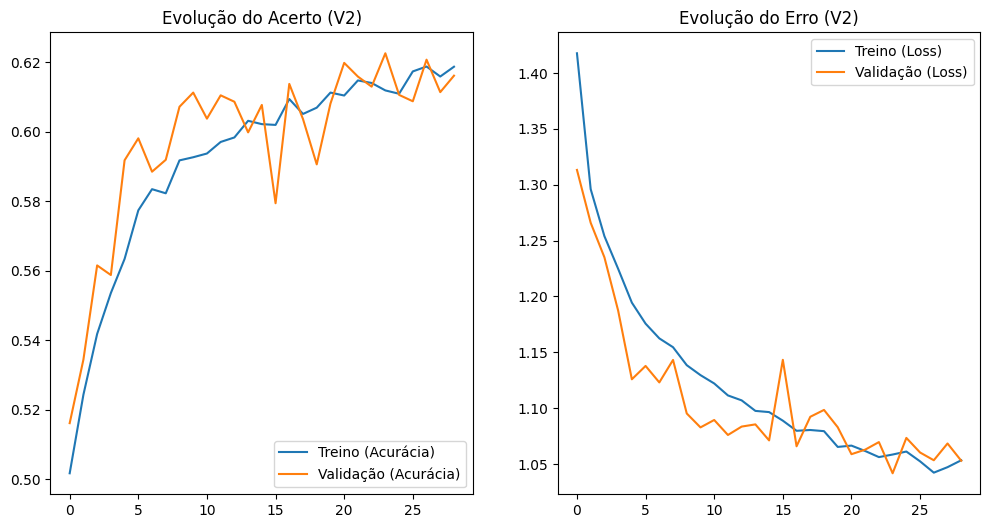

✅ SUCESSO! Modelo V2 salvo em: /content/drive/MyDrive/PIBIC_Melanoma/modelo_treinado_v2_melhorado.keras


In [ ]:

import os
import zipfile
import shutil
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
from google.colab import drive

# --- 1. CONFIGURAÇÃO E ACESSO AO DRIVE ---
print("🔌 Conectando ao Google Drive...")
drive.mount('/content/drive')

# Caminhos dos arquivos
caminho_zip_drive = '/content/drive/MyDrive/PIBIC_Melanoma/dataset_PRONTO.zip'
pasta_dataset = '/content/dataset_final'
local_zip = '/content/dataset_pronto.zip'

# --- 2. CARREGAMENTO DOS DADOS ---
if not os.path.exists(pasta_dataset):
    print("📦 Extraindo dataset do backup (Aguarde)...")
    if not os.path.exists(caminho_zip_drive):
        raise FileNotFoundError(f"Backup zip não encontrado em: {caminho_zip_drive}")

    shutil.copy(caminho_zip_drive, local_zip)
    with zipfile.ZipFile(local_zip, 'r') as zip_ref:
        zip_ref.extractall(pasta_dataset)

    # Limpeza
    for intruso in ['ISIC_2019_Training_Input', 'UNK']:
        path = os.path.join(pasta_dataset, intruso)
        if os.path.exists(path): shutil.rmtree(path)

    # Ajuste automático de pastas
    top_dirs = [d for d in os.listdir(pasta_dataset) if os.path.isdir(os.path.join(pasta_dataset, d))]
    if len(top_dirs) == 1:
        candidate = os.path.join(pasta_dataset, top_dirs[0])
        subdirs = [d for d in os.listdir(candidate) if os.path.isdir(os.path.join(candidate, d))]
        if len(subdirs) > 0:
            pasta_dataset = candidate
            print(f"⚙️ Ajustei pasta_dataset para: {pasta_dataset}")

    print("✅ Dataset extraído e limpo!")
else:
    print("⚡ Dataset já está pronto para uso.")

# Configurações
batch_size = 32       # Aumentei levemente para estabilizar o gradiente
img_height = 180
img_width = 180

print(f"\n🔄 Carregando imagens (Divisão 70/30)...")

# Mantive sua divisão 70/30 que ficou boa para teste rigoroso
train_ds = tf.keras.utils.image_dataset_from_directory(
    pasta_dataset,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    pasta_dataset,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"✅ Classes identificadas ({num_classes}): {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(200).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# --- 3. ARQUITETURA DA REDE NEURAL (Melhorada - V2) ---
print("\n🧠 Construindo o modelo CNN com Regularização...")

# MUDANÇA 1: Data Augmentation (Varia as imagens no treino)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,          # Aplica a variação
    layers.Rescaling(1./255),   # Normaliza

    # Bloco 1
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),        # MUDANÇA 2: Dropout (Apaga 20% dos neurônios)

    # Bloco 2
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),        # Mais dificuldade para a rede

    # Bloco 3
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Classificação
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),        # Dropout forte na decisão final (50%)
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model.summary()

# --- 4. TREINAMENTO (Com Parada Inteligente) ---
print("\n🚀 INICIANDO TREINAMENTO (V2)...")

# MUDANÇA 3: Early Stopping
# Se a 'val_loss' não melhorar por 5 épocas seguidas, o treino para.
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,  # Aumentei para 30 (mas o Early Stopping pode parar antes)
    callbacks=[early_stopping]
)

# --- 5. RESULTADOS ---
print("\n📊 Gerando gráficos de desempenho...")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Ajuste automático do eixo X (já que o treino pode parar antes da época 30)
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Treino (Acurácia)')
plt.plot(epochs_range, val_acc, label='Validação (Acurácia)')
plt.legend(loc='lower right')
plt.title('Evolução do Acerto (V2)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Treino (Loss)')
plt.plot(epochs_range, val_loss, label='Validação (Loss)')
plt.legend(loc='upper right')
plt.title('Evolução do Erro (V2)')
plt.show()

# Salva a versão V2
caminho_modelo = '/content/drive/MyDrive/PIBIC_Melanoma/modelo_treinado_v2_melhorado.keras'
model.save(caminho_modelo)
print(f"✅ SUCESSO! Modelo V2 salvo em: {caminho_modelo}")